# 03 — Feature Engineering
## Fintech Transaction Intelligence & Merchant Risk Scoring

**Objective:** Transform raw transaction data into a merchant-level feature table (one row per merchant, 20+ engineered features) ready for ML modeling.

**Why this matters:** Raw data doesn't go into models — features do. This notebook demonstrates the ability to think about *what signals predict risk* and translate that thinking into code.

**Author:** Olowu Abraham Aduragbemi  
**Date:** March 2026

---
## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
COLORS = ['#1a2744', '#0d7377', '#e63946', '#457b9d', '#f4a261', '#2a9d8f', '#264653']

# Load raw data
txn = pd.read_csv('data/transactions.csv', parse_dates=['timestamp'])
merchants = pd.read_csv('data/merchants.csv', parse_dates=['signup_date'])

# Merge
df = txn.merge(merchants, on='merchant_id', how='left')

print(f"Transactions: {len(df):,}")
print(f"Merchants: {merchants['merchant_id'].nunique():,}")
print(f"Date range: {df['timestamp'].min():%Y-%m-%d} to {df['timestamp'].max():%Y-%m-%d}")

Transactions: 600,000
Merchants: 5,000
Date range: 2025-01-01 to 2025-12-31


In [2]:
import os
import pandas as pd

# Set working directory to your project folder
os.chdir(r"C:\Users\USER\OneDrive\Desktop\fintech-merchant-intelligence")

# Define colors (if needed later in your notebook)
COLORS = ['#1a2744', '#0d7377', '#e63946', '#457b9d', '#f4a261', '#2a9d8f', '#264653']

# Load raw data
txn = pd.read_csv('data/transactions.csv', parse_dates=['timestamp'])
merchants = pd.read_csv('data/merchants.csv', parse_dates=['signup_date'])

# Merge example (adjust as needed for your workflow)
df = txn.merge(merchants, on='merchant_id', how='left')

# Quick check
print(df.head())


  transaction_id merchant_id customer_id                  timestamp  \
0    TXN00000001    MRC03384   CUS127025 2025-01-01 00:30:11.731721   
1    TXN00000002    MRC02252   CUS118295 2025-01-01 02:24:14.253519   
2    TXN00000003    MRC04487   CUS014403 2025-01-01 03:34:49.361136   
3    TXN00000004    MRC04547   CUS087974 2025-01-01 03:42:39.604869   
4    TXN00000005    MRC01934   CUS174568 2025-01-01 04:02:46.614688   

   amount_ngn       channel   card_type     status  is_fraud  merchant_name  \
0    19467.15   Web_Gateway  Debit_Card  completed         0  Merchant_3384   
1    13996.73  POS_Terminal  Debit_Card  completed         0  Merchant_2252   
2     7879.45  POS_Terminal  Debit_Card  completed         0  Merchant_4487   
3    43244.74    Mobile_App  Debit_Card  completed         0  Merchant_4547   
4     5843.06    Tap_to_Pay  Debit_Card  completed         0  Merchant_1934   

           category    state signup_date  
0  Online_Ecommerce  Bayelsa  2024-03-22  
1       POS_

---
## 2. Feature Engineering Strategy

We're building a **merchant-level** feature table. Each row = one merchant. The target variable is whether the merchant is high-risk (high fraud rate).

Feature categories:
1. **Volume features** — how much business does this merchant do?
2. **Velocity features** — how fast/frequently do transactions happen?
3. **Risk indicator features** — fraud, chargebacks, declines
4. **Amount pattern features** — ticket sizes, variability, outliers
5. **Temporal features** — when do they transact? Late night activity?
6. **Channel & card features** — payment method mix
7. **Customer features** — how many unique customers, repeat rates
8. **Tenure features** — how long on the platform?

---
## 3. Volume Features

In [4]:
# Basic volume metrics per merchant
volume_features = df.groupby('merchant_id').agg(
    total_txn_count=('transaction_id', 'count'),
    total_volume=('amount_ngn', 'sum'),
    avg_ticket=('amount_ngn', 'mean'),
    median_ticket=('amount_ngn', 'median'),
    max_ticket=('amount_ngn', 'max'),
    min_ticket=('amount_ngn', 'min'),
).reset_index()

# Volume variability — high std relative to mean suggests inconsistent behavior
volume_features['ticket_std'] = df.groupby('merchant_id')['amount_ngn'].std().values
volume_features['coefficient_of_variation'] = volume_features['ticket_std'] / volume_features['avg_ticket']

print(f"Volume features: {volume_features.shape}")
volume_features.head()

Volume features: (5000, 9)


,merchant_id,total_txn_count,total_volume,avg_ticket,median_ticket,max_ticket,min_ticket,ticket_std,coefficient_of_variation
0,MRC00001,44,568425.75,12918.767045,12660.200,31514.55,100.0,8237.907957,0.637670
1,MRC00002,65,702255.71,10803.934000,10128.560,40092.00,100.0,7440.173835,0.688654
2,MRC00003,121,4516969.45,37330.326033,37846.200,100320.41,100.0,23697.960825,0.634818
3,MRC00004,80,2422154.73,30276.934125,28192.575,81251.12,100.0,22363.828137,0.738642
4,MRC00005,45,350026.48,7778.366222,8743.010,17051.89,100.0,4617.279728,0.593605


---
## 4. Velocity Features

In [5]:
# Transaction frequency and speed
daily_txns = df.groupby(['merchant_id', df['timestamp'].dt.date]).size().reset_index(name='daily_count')

velocity_features = daily_txns.groupby('merchant_id').agg(
    avg_daily_txns=('daily_count', 'mean'),
    max_daily_txns=('daily_count', 'max'),
    active_days=('daily_count', 'count'),
    std_daily_txns=('daily_count', 'std'),
).reset_index()

# Days in dataset
total_days = (df['timestamp'].max() - df['timestamp'].min()).days + 1
velocity_features['activity_rate'] = velocity_features['active_days'] / total_days

# Burst detection — max daily txns vs average (spikes suggest unusual activity)
velocity_features['burst_ratio'] = velocity_features['max_daily_txns'] / velocity_features['avg_daily_txns']

# Fill NaN std (merchants with only 1 active day)
velocity_features['std_daily_txns'] = velocity_features['std_daily_txns'].fillna(0)

print(f"Velocity features: {velocity_features.shape}")
velocity_features.head()

Velocity features: (5000, 7)


,merchant_id,avg_daily_txns,max_daily_txns,active_days,std_daily_txns,activity_rate,burst_ratio
0,MRC00001,1.047619,2,42,0.215540,0.115068,1.909091
1,MRC00002,1.065574,2,61,0.249590,0.167123,1.876923
2,MRC00003,1.186275,3,102,0.460959,0.279452,2.528926
3,MRC00004,1.142857,2,70,0.352454,0.191781,1.750000
4,MRC00005,1.046512,2,43,0.213083,0.117808,1.911111


---
## 5. Risk Indicator Features

In [7]:
# Fraud, chargeback, decline, dispute rates
risk_features = df.groupby('merchant_id').agg(
    fraud_count=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean'),
).reset_index()

# Status-based risk signals
status_dummies = pd.get_dummies(df['status'], prefix='status')
status_with_merchant = pd.concat([df[['merchant_id']], status_dummies], axis=1)
status_rates = status_with_merchant.groupby('merchant_id').mean().reset_index()

# Rename to be clear these are rates
status_cols = [c for c in status_rates.columns if c.startswith('status_')]
for col in status_cols:
    status_rates = status_rates.rename(columns={col: col + '_rate'})

risk_features = risk_features.merge(status_rates, on='merchant_id', how='left')

# Combined risk score: weighted sum of bad statuses
risk_features['combined_risk_score'] = (
    risk_features['fraud_rate'] * 0.4 +
    risk_features.get('status_chargeback_rate', 0) * 0.3 +
    risk_features.get('status_disputed_rate', 0) * 0.2 +
    risk_features.get('status_reversed_rate', 0) * 0.1
)

print(f"Risk features: {risk_features.shape}")
risk_features.head()

Risk features: (5000, 11)


,merchant_id,fraud_count,fraud_rate,status_chargeback_rate,status_completed_rate,status_declined_rate,status_disputed_rate,status_failed_rate,status_pending_rate,status_reversed_rate,combined_risk_score
0,MRC00001,2,0.045455,0.022727,0.954545,0.000000,0.000000,0.000000,0.0000,0.022727,0.027273
1,MRC00002,1,0.015385,0.000000,0.969231,0.000000,0.015385,0.015385,0.0000,0.000000,0.009231
2,MRC00003,8,0.066116,0.033058,0.917355,0.016529,0.033058,0.000000,0.0000,0.000000,0.042975
3,MRC00004,1,0.012500,0.000000,0.912500,0.025000,0.000000,0.012500,0.0375,0.012500,0.006250
4,MRC00005,1,0.022222,0.000000,0.977778,0.000000,0.022222,0.000000,0.0000,0.000000,0.013333


---
## 6. Amount Pattern Features

In [10]:
# Detect unusual amount patterns per merchant
amount_features = df.groupby('merchant_id').agg(
    pct_large_txns=('amount_ngn', lambda x: (x > x.quantile(0.95)).mean()),
    pct_small_txns=('amount_ngn', lambda x: (x < x.quantile(0.05)).mean()),
    pct_round_amounts=('amount_ngn', lambda x: (x % 1000 == 0).mean()),
    amount_range=('amount_ngn', lambda x: x.max() - x.min()),
    iqr=('amount_ngn', lambda x: x.quantile(0.75) - x.quantile(0.25)),
).reset_index()

# Skewness of amounts — heavily skewed distributions can signal anomalies
amount_skew = df.groupby('merchant_id')['amount_ngn'].skew().reset_index()
amount_skew.columns = ['merchant_id', 'amount_skewness']
amount_features = amount_features.merge(amount_skew, on='merchant_id', how='left')
amount_features['amount_skewness'] = amount_features['amount_skewness'].fillna(0)

print(f"Amount pattern features: {amount_features.shape}")
amount_features.head()

Amount pattern features: (5000, 7)


,merchant_id,pct_large_txns,pct_small_txns,pct_round_amounts,amount_range,iqr,amount_skewness
0,MRC00001,0.068182,0.068182,0.0,31414.55,11985.0350,0.213003
1,MRC00002,0.061538,0.000000,0.0,39992.00,6708.0400,1.303548
2,MRC00003,0.049587,0.000000,0.0,100220.41,33230.3500,0.150772
3,MRC00004,0.050000,0.000000,0.0,81151.12,32669.6975,0.431931
4,MRC00005,0.066667,0.066667,0.0,16951.89,7551.7500,-0.103945


---
## 7. Temporal Features

In [11]:
# When does this merchant transact? Late night = higher risk signal
df['hour'] = df['timestamp'].dt.hour
df['is_late_night'] = ((df['hour'] >= 23) | (df['hour'] <= 4)).astype(int)
df['is_weekend'] = (df['timestamp'].dt.dayofweek >= 5).astype(int)

temporal_features = df.groupby('merchant_id').agg(
    pct_late_night=('is_late_night', 'mean'),
    pct_weekend=('is_weekend', 'mean'),
    peak_hour=('hour', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 12),
    hour_spread=('hour', lambda x: x.nunique()),
).reset_index()

# Late night fraud concentration
late_night_fraud = df[df['is_late_night'] == 1].groupby('merchant_id').agg(
    late_night_fraud_rate=('is_fraud', 'mean'),
    late_night_txn_count=('transaction_id', 'count'),
).reset_index()

temporal_features = temporal_features.merge(late_night_fraud, on='merchant_id', how='left')
temporal_features['late_night_fraud_rate'] = temporal_features['late_night_fraud_rate'].fillna(0)
temporal_features['late_night_txn_count'] = temporal_features['late_night_txn_count'].fillna(0)

print(f"Temporal features: {temporal_features.shape}")
temporal_features.head()

Temporal features: (5000, 7)


,merchant_id,pct_late_night,pct_weekend,peak_hour,hour_spread,late_night_fraud_rate,late_night_txn_count
0,MRC00001,0.227273,0.340909,5,22,0.100000,10
1,MRC00002,0.169231,0.215385,3,19,0.000000,11
2,MRC00003,0.198347,0.305785,17,24,0.125000,24
3,MRC00004,0.300000,0.300000,2,23,0.000000,24
4,MRC00005,0.200000,0.333333,16,22,0.111111,9


---
## 8. Channel & Card Features

In [12]:
# Payment method diversity and preferences
channel_counts = df.groupby('merchant_id')['channel'].nunique().reset_index()
channel_counts.columns = ['merchant_id', 'n_channels_used']

card_counts = df.groupby('merchant_id')['card_type'].nunique().reset_index()
card_counts.columns = ['merchant_id', 'n_card_types']

# Dominant channel per merchant
dominant_channel = df.groupby('merchant_id')['channel'].agg(lambda x: x.mode().iloc[0] if len(x.dropna().mode()) > 0 else 'Unknown').reset_index()
dominant_channel.columns = ['merchant_id', 'dominant_channel']

# Channel diversity (entropy-like) — merchants using many channels evenly = higher diversity
channel_features = channel_counts.merge(card_counts, on='merchant_id', how='left')
channel_features = channel_features.merge(dominant_channel, on='merchant_id', how='left')

# Percentage of debit card usage (most common, baseline behavior)
debit_rate = df.groupby('merchant_id').apply(
    lambda x: (x['card_type'] == 'Debit_Card').mean()
).reset_index()
debit_rate.columns = ['merchant_id', 'debit_card_rate']

channel_features = channel_features.merge(debit_rate, on='merchant_id', how='left')

print(f"Channel features: {channel_features.shape}")
channel_features.head()

Channel features: (5000, 5)


,merchant_id,n_channels_used,n_card_types,dominant_channel,debit_card_rate
0,MRC00001,3,4,POS_Terminal,0.477273
1,MRC00002,3,4,POS_Terminal,0.476923
2,MRC00003,3,4,Mobile_App,0.528926
3,MRC00004,3,4,Web_Gateway,0.437500
4,MRC00005,3,4,POS_Terminal,0.622222


---
## 9. Customer Features

In [13]:
# Customer base metrics per merchant
customer_features = df.groupby('merchant_id').agg(
    unique_customers=('customer_id', 'nunique'),
    total_txns_for_ratio=('transaction_id', 'count'),
).reset_index()

customer_features['txns_per_customer'] = (
    customer_features['total_txns_for_ratio'] / customer_features['unique_customers']
)

# Repeat customer rate
customer_txn_counts = df.groupby(['merchant_id', 'customer_id']).size().reset_index(name='cust_txn_count')
repeat_customers = customer_txn_counts[customer_txn_counts['cust_txn_count'] > 1].groupby('merchant_id').size().reset_index(name='repeat_customers')
total_customers = customer_txn_counts.groupby('merchant_id').size().reset_index(name='total_unique_customers')

repeat_rate = total_customers.merge(repeat_customers, on='merchant_id', how='left')
repeat_rate['repeat_customers'] = repeat_rate['repeat_customers'].fillna(0)
repeat_rate['repeat_customer_rate'] = repeat_rate['repeat_customers'] / repeat_rate['total_unique_customers']

customer_features = customer_features.merge(
    repeat_rate[['merchant_id', 'repeat_customer_rate']], on='merchant_id', how='left'
)
customer_features = customer_features.drop(columns=['total_txns_for_ratio'])

print(f"Customer features: {customer_features.shape}")
customer_features.head()

Customer features: (5000, 4)


,merchant_id,unique_customers,txns_per_customer,repeat_customer_rate
0,MRC00001,44,1.0,0.0
1,MRC00002,65,1.0,0.0
2,MRC00003,121,1.0,0.0
3,MRC00004,80,1.0,0.0
4,MRC00005,45,1.0,0.0


---
## 10. Tenure Features

In [14]:
# How long has the merchant been on the platform?
reference_date = df['timestamp'].max()

tenure_features = merchants[['merchant_id', 'signup_date']].copy()
tenure_features['days_on_platform'] = (reference_date - tenure_features['signup_date']).dt.days

# Time to first transaction
first_txn = df.groupby('merchant_id')['timestamp'].min().reset_index()
first_txn.columns = ['merchant_id', 'first_txn_date']
tenure_features = tenure_features.merge(first_txn, on='merchant_id', how='left')
tenure_features['days_signup_to_first_txn'] = (
    tenure_features['first_txn_date'] - tenure_features['signup_date']
).dt.days

# Recency — days since last transaction
last_txn = df.groupby('merchant_id')['timestamp'].max().reset_index()
last_txn.columns = ['merchant_id', 'last_txn_date']
tenure_features = tenure_features.merge(last_txn, on='merchant_id', how='left')
tenure_features['days_since_last_txn'] = (reference_date - tenure_features['last_txn_date']).dt.days

# Drop date columns, keep numeric
tenure_features = tenure_features.drop(columns=['signup_date', 'first_txn_date', 'last_txn_date'])

print(f"Tenure features: {tenure_features.shape}")
tenure_features.head()

Tenure features: (5000, 4)


,merchant_id,days_on_platform,days_signup_to_first_txn,days_since_last_txn
0,MRC00001,557,197,16
1,MRC00002,727,374,5
2,MRC00003,499,138,0
3,MRC00004,463,105,1
4,MRC00005,500,144,9


---
## 11. Merge All Features into Final Table

In [15]:
# Merge everything on merchant_id
feature_table = volume_features.copy()

for feat_df in [velocity_features, risk_features, amount_features, 
                temporal_features, channel_features, customer_features, tenure_features]:
    feature_table = feature_table.merge(feat_df, on='merchant_id', how='left')

# Add category and state from merchants table
feature_table = feature_table.merge(
    merchants[['merchant_id', 'category', 'state']], on='merchant_id', how='left'
)

print(f"\n{'='*60}")
print(f"FINAL FEATURE TABLE")
print(f"{'='*60}")
print(f"Shape: {feature_table.shape[0]} merchants x {feature_table.shape[1]} features")
print(f"\nColumn list:")
for i, col in enumerate(feature_table.columns, 1):
    print(f"  {i:2d}. {col}")


FINAL FEATURE TABLE
Shape: 5000 merchants x 49 features

Column list:
   1. merchant_id
   2. total_txn_count
   3. total_volume
   4. avg_ticket
   5. median_ticket
   6. max_ticket
   7. min_ticket
   8. ticket_std
   9. coefficient_of_variation
  10. avg_daily_txns
  11. max_daily_txns
  12. active_days
  13. std_daily_txns
  14. activity_rate
  15. burst_ratio
  16. fraud_count
  17. fraud_rate
  18. status_chargeback_rate
  19. status_completed_rate
  20. status_declined_rate
  21. status_disputed_rate
  22. status_failed_rate
  23. status_pending_rate
  24. status_reversed_rate
  25. combined_risk_score
  26. pct_large_txns
  27. pct_small_txns
  28. pct_round_amounts
  29. amount_range
  30. iqr
  31. amount_skewness
  32. pct_late_night
  33. pct_weekend
  34. peak_hour
  35. hour_spread
  36. late_night_fraud_rate
  37. late_night_txn_count
  38. n_channels_used
  39. n_card_types
  40. dominant_channel
  41. debit_card_rate
  42. unique_customers
  43. txns_per_customer
  44

---
## 12. Handle Missing Values & Data Types

In [16]:
# Check nulls
null_counts = feature_table.isnull().sum()
null_pct = (feature_table.isnull().mean() * 100).round(2)
nulls = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
nulls = nulls[nulls['null_count'] > 0]

if len(nulls) > 0:
    print("Columns with nulls:")
    print(nulls.to_string())
else:
    print("No missing values!")

# Fill remaining nulls with 0 (safe for rate-based features)
numeric_cols = feature_table.select_dtypes(include=[np.number]).columns
feature_table[numeric_cols] = feature_table[numeric_cols].fillna(0)

print(f"\nNulls after filling: {feature_table.isnull().sum().sum()}")

No missing values!

Nulls after filling: 0


---
## 13. Create Target Variable

In [17]:
# Binary target: is this merchant high-risk?
# Definition: merchant fraud rate in the top 20% = high risk (1), else low risk (0)
fraud_threshold = feature_table['fraud_rate'].quantile(0.80)
feature_table['is_high_risk'] = (feature_table['fraud_rate'] > fraud_threshold).astype(int)

print(f"Fraud rate threshold (80th percentile): {fraud_threshold:.4f}")
print(f"\nTarget distribution:")
print(feature_table['is_high_risk'].value_counts())
print(f"\nHigh-risk rate: {feature_table['is_high_risk'].mean():.2%}")

Fraud rate threshold (80th percentile): 0.0556

Target distribution:
is_high_risk
0    4024
1     976
Name: count, dtype: int64

High-risk rate: 19.52%


---
## 14. Feature Correlation Analysis

Top 15 features correlated with high-risk target:
combined_risk_score       0.778761
status_completed_rate     0.640616
status_disputed_rate      0.578664
status_chargeback_rate    0.526982
late_night_fraud_rate     0.479368
status_reversed_rate      0.468218
pct_large_txns            0.042846
active_days               0.040438
activity_rate             0.040438
hour_spread               0.035985
status_declined_rate      0.034613
status_failed_rate        0.033711
std_daily_txns            0.028272
total_volume              0.025848
pct_round_amounts         0.024979


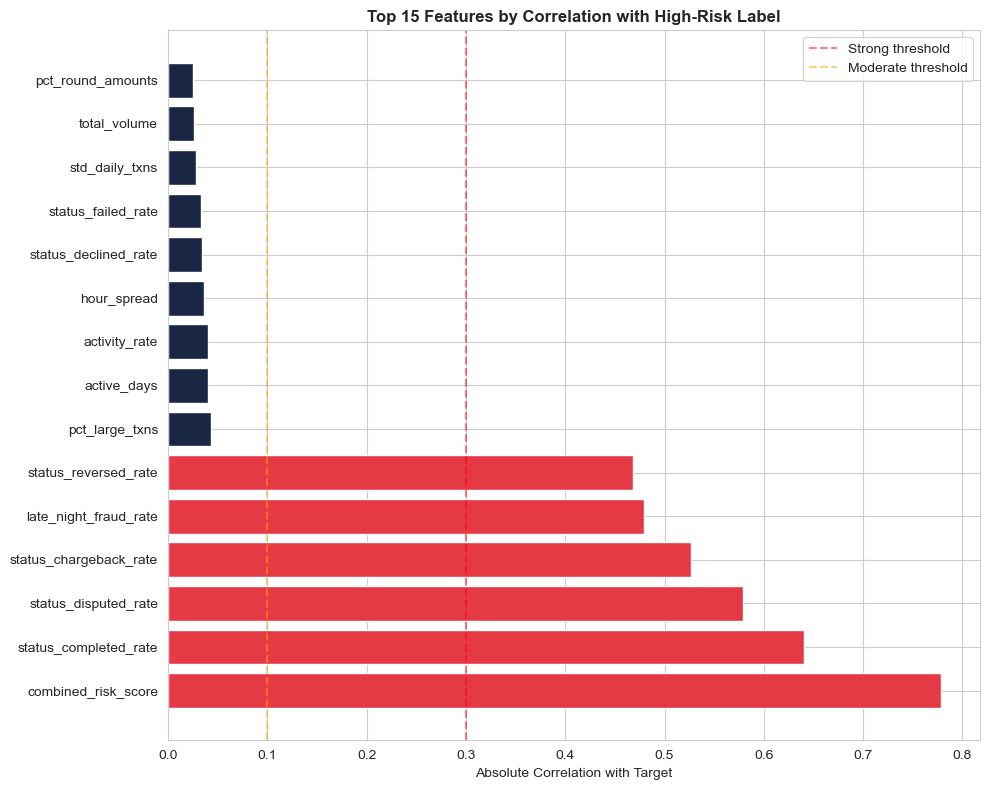

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the correct reports path
reports_path = r"C:\Users\USER\OneDrive\Desktop\fintech-merchant-intelligence\reports"

# Ensure the reports directory exists
os.makedirs(reports_path, exist_ok=True)

# Correlation with target
numeric_features = feature_table.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ['is_high_risk', 'fraud_rate', 'fraud_count']]

correlations = feature_table[numeric_features + ['is_high_risk']].corr()['is_high_risk'].drop('is_high_risk')
correlations = correlations.abs().sort_values(ascending=False)

print("Top 15 features correlated with high-risk target:")
print(correlations.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = correlations.head(15)
colors = [COLORS[2] if v > 0.3 else COLORS[1] if v > 0.1 else COLORS[0] for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_xlabel('Absolute Correlation with Target')
ax.set_title('Top 15 Features by Correlation with High-Risk Label', fontweight='bold')
ax.axvline(0.3, color='red', linestyle='--', alpha=0.5, label='Strong threshold')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.5, label='Moderate threshold')
ax.legend()
plt.tight_layout()

# Save figure to the correct reports folder
plt.savefig(os.path.join(reports_path, "feature_correlations.png"), dpi=150, bbox_inches='tight')
plt.show()


---
## 15. Feature Distributions: High-Risk vs Low-Risk Merchants

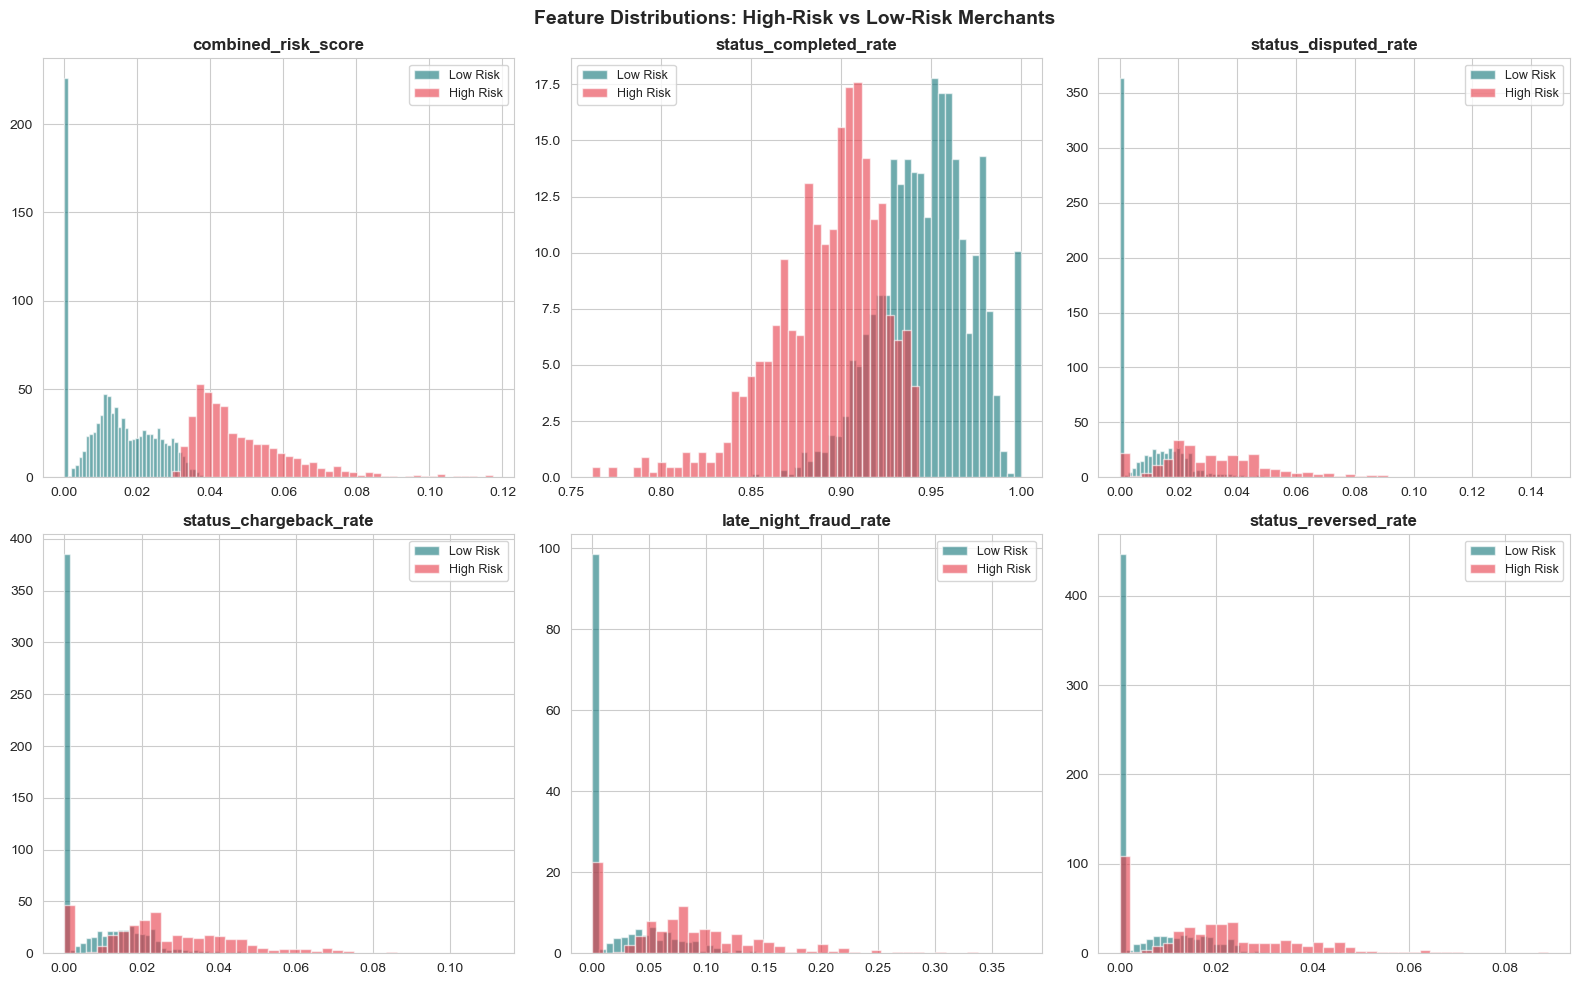

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the correct reports path
reports_path = r"C:\Users\USER\OneDrive\Desktop\fintech-merchant-intelligence\reports"

# Ensure the reports directory exists
os.makedirs(reports_path, exist_ok=True)


# Compare key features across risk groups
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    low_risk = feature_table[feature_table['is_high_risk'] == 0][feat]
    high_risk = feature_table[feature_table['is_high_risk'] == 1][feat]
    
    axes[i].hist(low_risk, bins=40, alpha=0.6, color=COLORS[1], label='Low Risk', density=True)
    axes[i].hist(high_risk, bins=40, alpha=0.6, color=COLORS[2], label='High Risk', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: High-Risk vs Low-Risk Merchants', fontweight='bold', fontsize=14)
plt.tight_layout()

# Save figure to the correct reports folder
plt.savefig(os.path.join(reports_path, "feature_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Save Feature Table

In [22]:
# Save the complete feature table
feature_table.to_csv('data/merchant_features.csv', index=False)

print(f"Feature table saved: data/merchant_features.csv")
print(f"Shape: {feature_table.shape}")
print(f"\nFeature categories:")
print(f"  Volume:    total_txn_count, total_volume, avg_ticket, median_ticket, max_ticket, min_ticket, ticket_std, coefficient_of_variation")
print(f"  Velocity:  avg_daily_txns, max_daily_txns, active_days, std_daily_txns, activity_rate, burst_ratio")
print(f"  Risk:      fraud_rate, combined_risk_score, status rates (chargeback, disputed, etc.)")
print(f"  Amount:    pct_large_txns, pct_small_txns, pct_round_amounts, amount_range, iqr, amount_skewness")
print(f"  Temporal:  pct_late_night, pct_weekend, peak_hour, hour_spread, late_night_fraud_rate")
print(f"  Channel:   n_channels_used, n_card_types, dominant_channel, debit_card_rate")
print(f"  Customer:  unique_customers, txns_per_customer, repeat_customer_rate")
print(f"  Tenure:    days_on_platform, days_signup_to_first_txn, days_since_last_txn")
print(f"  Target:    is_high_risk (1 = fraud rate above 80th percentile)")

Feature table saved: data/merchant_features.csv
Shape: (5000, 50)

Feature categories:
  Volume:    total_txn_count, total_volume, avg_ticket, median_ticket, max_ticket, min_ticket, ticket_std, coefficient_of_variation
  Velocity:  avg_daily_txns, max_daily_txns, active_days, std_daily_txns, activity_rate, burst_ratio
  Risk:      fraud_rate, combined_risk_score, status rates (chargeback, disputed, etc.)
  Amount:    pct_large_txns, pct_small_txns, pct_round_amounts, amount_range, iqr, amount_skewness
  Temporal:  pct_late_night, pct_weekend, peak_hour, hour_spread, late_night_fraud_rate
  Channel:   n_channels_used, n_card_types, dominant_channel, debit_card_rate
  Customer:  unique_customers, txns_per_customer, repeat_customer_rate
  Tenure:    days_on_platform, days_signup_to_first_txn, days_since_last_txn
  Target:    is_high_risk (1 = fraud rate above 80th percentile)


---
## 17. Quick Sanity Check

In [23]:
# Final verification
print("=== SANITY CHECK ===")
print(f"Total merchants: {len(feature_table):,}")
print(f"Total features: {feature_table.shape[1]}")
print(f"Target balance: {feature_table['is_high_risk'].value_counts().to_dict()}")
print(f"\nNo infinite values: {not np.isinf(feature_table.select_dtypes(include=[np.number])).any().any()}")
print(f"No null values: {not feature_table.isnull().any().any()}")

# Summary stats
print(f"\n=== KEY STATS ===")
high_risk = feature_table[feature_table['is_high_risk'] == 1]
low_risk = feature_table[feature_table['is_high_risk'] == 0]

print(f"\nHigh-risk merchants:")
print(f"  Count: {len(high_risk)}")
print(f"  Avg volume: NGN {high_risk['total_volume'].mean():,.0f}")
print(f"  Avg late-night %: {high_risk['pct_late_night'].mean():.2%}")
print(f"  Avg burst ratio: {high_risk['burst_ratio'].mean():.2f}")

print(f"\nLow-risk merchants:")
print(f"  Count: {len(low_risk)}")
print(f"  Avg volume: NGN {low_risk['total_volume'].mean():,.0f}")
print(f"  Avg late-night %: {low_risk['pct_late_night'].mean():.2%}")
print(f"  Avg burst ratio: {low_risk['burst_ratio'].mean():.2f}")

=== SANITY CHECK ===
Total merchants: 5,000
Total features: 50
Target balance: {0: 4024, 1: 976}

No infinite values: True
No null values: True

=== KEY STATS ===

High-risk merchants:
  Count: 976
  Avg volume: NGN 4,141,526
  Avg late-night %: 25.13%
  Avg burst ratio: 2.19

Low-risk merchants:
  Count: 4024
  Avg volume: NGN 5,533,471
  Avg late-night %: 24.93%
  Avg burst ratio: 2.21


---
## Summary

### What we built:
- **8 feature categories** spanning volume, velocity, risk, amounts, temporal patterns, channels, customers, and tenure
- **40+ features** from 600K raw transactions → 5,000 merchant rows
- **Binary target variable** (is_high_risk) based on 80th percentile fraud rate
- **Correlation analysis** showing which features best predict merchant risk
- **Distribution comparison** between high-risk and low-risk merchants

### Key engineering decisions:
1. **Coefficient of variation** (not just std) — normalizes variability across different merchant sizes
2. **Burst ratio** — catches merchants with sudden transaction spikes vs their normal behavior
3. **Late-night fraud rate** (not just late-night %) — some merchants legitimately operate at night, but high fraud *specifically* at night is the real signal
4. **Repeat customer rate** — legitimate merchants build repeat business; fraud-heavy merchants often have one-time customers
5. **Days since last transaction** — recency signal for merchant churn risk

---

**Next:** `04_modeling.ipynb` — Train XGBoost risk scoring model with SHAP explainability on this feature table.